In [2]:
import numpy as np
import matplotlib.pyplot as plt
# plt.style.use('seaborn-whitegrid')
# from domain_gap.WassDist_eval import (
#     get_layerwise_dist, 
#     plot_average_Wassdist, 
#     plot_Wassdist_layerwise,
# )
import h5py
import os
import scipy.stats

In [13]:
def plot_performance_vs_dist(
    performance_dict,
    hdiv_dict,
    title="Segmentation performance vs Wasserstein distance",
    xlabel="Wasserstein distance",
    ylabel="Performance (F1-score)",
    colors=None,
    markers=None,
    figsize=(10, 7),
    fontsize=20,
    point_size=150,
    save_path="/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures",
    save_name="performance_vs_wass",
    x_ticks=None,
):
    """Scatter-plot segmentation performance against repeated h-divergence values."""
    shared_datasets = [dataset for dataset in performance_dict if dataset in hdiv_dict]
    if not shared_datasets:
        raise ValueError("No overlapping datasets found between performance and hdiv dictionaries.")

    if colors is None:
        colors = {
            "EPFL": "#4C78A8",
            "Hmito": "#F58518",
            "Rmito": "#54A24B",
            "VNC": "#C44E52",
        }
    if markers is None:
        markers = {
            "EPFL": "^",
            "Hmito": "o",
            "Rmito": "s",
            "VNC": "D",
        }

    fig, ax = plt.subplots(figsize=figsize)

    for dataset in shared_datasets:
        hdiv_values = list(hdiv_dict[dataset])
        if not isinstance(hdiv_values, (list, tuple)):
            raise ValueError(f"H-divergence values for {dataset} must be a list or tuple.")

        x_values = list(hdiv_values)
        y_values = list(performance_dict[dataset])
        _= ax.scatter(
            x_values,
            y_values,
            s=point_size,
            color=colors.get(dataset, None),
            marker=markers.get(dataset, "o"),
            edgecolor="black",
            linewidth=0.6,
            label=dataset,
        )

    _ =ax.set_xlabel(xlabel, fontsize=fontsize)
    _ =ax.set_ylabel(ylabel, fontsize=fontsize)
    _ =ax.set_title(title, fontsize=fontsize)
    _ =ax.grid(True, linestyle="--", alpha=0.35)
    _ =ax.legend(frameon=False, loc="best", fontsize=fontsize - 2)
    _ =ax.tick_params(axis="both", labelsize=fontsize - 2)

    if x_ticks is not None:
        ax.set_xticks(list(x_ticks))
        ax.set_xticklabels([f"{tick:.3f}" for tick in x_ticks])

    plt.tight_layout()
    plt.savefig(f"{save_path}/{save_name}.svg", format="svg", bbox_inches=None)
    plt.show()

In [3]:
def get_layerwise_dist(
    source: str,
    target: str,
    num_repeats: int,
    save_name_postfix: str,
    start_id: int = 1,
    distance: str = "OT",
    layers: list = None,
    xlim: tuple = (0, 0.5),
    ylim: tuple = (0.7, 1),
):
    f1_scores = np.zeros(num_repeats)
    layer_dists = {}
    for i in range(num_repeats):
        id = start_id + i
        data_path = get_layerwisepath(source, target, id, save_name_postfix, distance)
        with h5py.File(data_path, "r") as f:
            _, _, _, f1_scores[i] = prediction_evaluation(
                f["prediction"], f["gt_labels"]
            )
            for layer in layers:
                layer_dists[f"{layer}_{id}"] = f[f"{layer}dist"][()]
    return f1_scores, layer_dists

In [4]:
def get_layerwisepath(
    source: str,
    target: str,
    id: int,
    save_name_postfix: str,
    distance: str = "OT",
):
    folderpath = (
        f"/g/kreshuk/talks/domain_gap/experiments/patch_classification"
        + f"/{source}_to_{target}/{distance}/predictions"
    )
    filename = (
        f"{distance}_{source[0].upper()}to{target[0].upper()}_"
        + f"{save_name_postfix}_{id}.h5"
    )
    return os.path.join(folderpath, filename)

In [5]:
import sklearn.metrics as metrics

def prediction_evaluation(predictions, labels):
    accuracy_error = 1.0 - metrics.accuracy_score(labels, predictions)
    precision = metrics.precision_score(labels, predictions)
    recall = metrics.recall_score(labels, predictions)
    f1_score = metrics.f1_score(labels, predictions)
    return accuracy_error, precision, recall, f1_score

# Load Data

In [6]:
feature_layers = ["layer1", "layer2", "layer3", "layer4", "avgpool"]

In [7]:
HtoE_f1s, HtoE_dists = get_layerwise_dist("Hmito", "epfl", 3, "multi", 1, layers=feature_layers)
HtoH_f1s, HtoH_dists = get_layerwise_dist("Hmito", "Hmito", 3, "multi", 1, layers=feature_layers)
HtoR_f1s, HtoR_dists = get_layerwise_dist("Hmito", "Rmito", 3, "multi", 1, layers=feature_layers)
HtoV_f1s, HtoV_dists = get_layerwise_dist("Hmito", "VNC", 3, "multi", 1, layers=feature_layers)

In [29]:
EtoE_f1s, EtoE_dists = get_layerwise_dist("epfl", "epfl", 1, "multi", 1, layers=feature_layers)
EtoH_f1s, EtoH_dists = get_layerwise_dist("epfl", "Hmito", 1, "multi", 1, layers=feature_layers)
EtoR_f1s, EtoR_dists = get_layerwise_dist("epfl", "Rmito", 1, "multi", 1, layers=feature_layers)
EtoV_f1s, EtoV_dists = get_layerwise_dist("epfl", "VNC", 1, "multi", 1, layers=feature_layers)

In [30]:
RtoE_f1s, RtoE_dists = get_layerwise_dist("Rmito", "epfl", 1, "multi", 1, layers=feature_layers)
RtoH_f1s, RtoH_dists = get_layerwise_dist("Rmito", "Hmito", 1, "multi", 1, layers=feature_layers)
RtoR_f1s, RtoR_dists = get_layerwise_dist("Rmito", "Rmito", 1, "multi", 1, layers=feature_layers)
RtoV_f1s, RtoV_dists = get_layerwise_dist("Rmito", "VNC", 1, "multi", 1, layers=feature_layers)

In [17]:
EtoE_f1s

array([0.956621])

In [10]:
HtoE_f1s

array([0.87724551, 0.87724551, 0.87724551])

In [11]:
HtoE_dists

{'layer1_1': array([0.29891479, 0.31731042]),
 'layer2_1': array([0.40174377, 0.3789809 ]),
 'layer3_1': array([0.35571644, 0.26592347]),
 'layer4_1': array([0.22985262, 0.1806592 ]),
 'avgpool_1': array([0.04744408, 0.04001583]),
 'layer1_2': array([0.29868704, 0.31745631]),
 'layer2_2': array([0.40168577, 0.37974387]),
 'layer3_2': array([0.35571346, 0.26777431]),
 'layer4_2': array([0.22977683, 0.18225786]),
 'avgpool_2': array([0.04744679, 0.04037732]),
 'layer1_3': array([0.29865992, 0.31748098]),
 'layer2_3': array([0.40167502, 0.37909764]),
 'layer3_3': array([0.35575783, 0.26652491]),
 'layer4_3': array([0.22980461, 0.1813408 ]),
 'avgpool_3': array([0.04750663, 0.04019371])}

# EPFL source

In [31]:
EPFL_f1s = {
    "EPFL": [EtoE_f1s[0]],
    "Hmito": [EtoH_f1s[0]],
    "Rmito": [EtoR_f1s[0]],
    "VNC": [EtoV_f1s[0]],
}
EPFL_wass1 = {
    "EPFL": [np.mean(EtoE_dists["layer1_1"], axis=0)],
    "Hmito": [np.mean(EtoH_dists["layer1_1"], axis=0)],
    "Rmito": [np.mean(EtoR_dists["layer1_1"], axis=0)],
    "VNC": [np.mean(EtoV_dists["layer1_1"], axis=0)],
}
EPFL_wass2 = {
    "EPFL": [np.mean(EtoE_dists["layer2_1"], axis=0)],
    "Hmito": [np.mean(EtoH_dists["layer2_1"], axis=0)],
    "Rmito": [np.mean(EtoR_dists["layer2_1"], axis=0)],
    "VNC": [np.mean(EtoV_dists["layer2_1"], axis=0)],
}
EPFL_wass3 = {
    "EPFL": [np.mean(EtoE_dists["layer3_1"], axis=0)],
    "Hmito": [np.mean(EtoH_dists["layer3_1"], axis=0)],
    "Rmito": [np.mean(EtoR_dists["layer3_1"], axis=0)],
    "VNC": [np.mean(EtoV_dists["layer3_1"], axis=0)],
}
EPFL_wass4 = {
    "EPFL": [np.mean(EtoE_dists["layer4_1"], axis=0)],
    "Hmito": [np.mean(EtoH_dists["layer4_1"], axis=0)],
    "Rmito": [np.mean(EtoR_dists["layer4_1"], axis=0)],
    "VNC": [np.mean(EtoV_dists["layer4_1"], axis=0)],
}
EPFL_wass_avgpool = {
    "EPFL": [np.mean(EtoE_dists["avgpool_1"], axis=0)],
    "Hmito": [np.mean(EtoH_dists["avgpool_1"], axis=0)],
    "Rmito": [np.mean(EtoR_dists["avgpool_1"], axis=0)],
    "VNC": [np.mean(EtoV_dists["avgpool_1"], axis=0)],
}

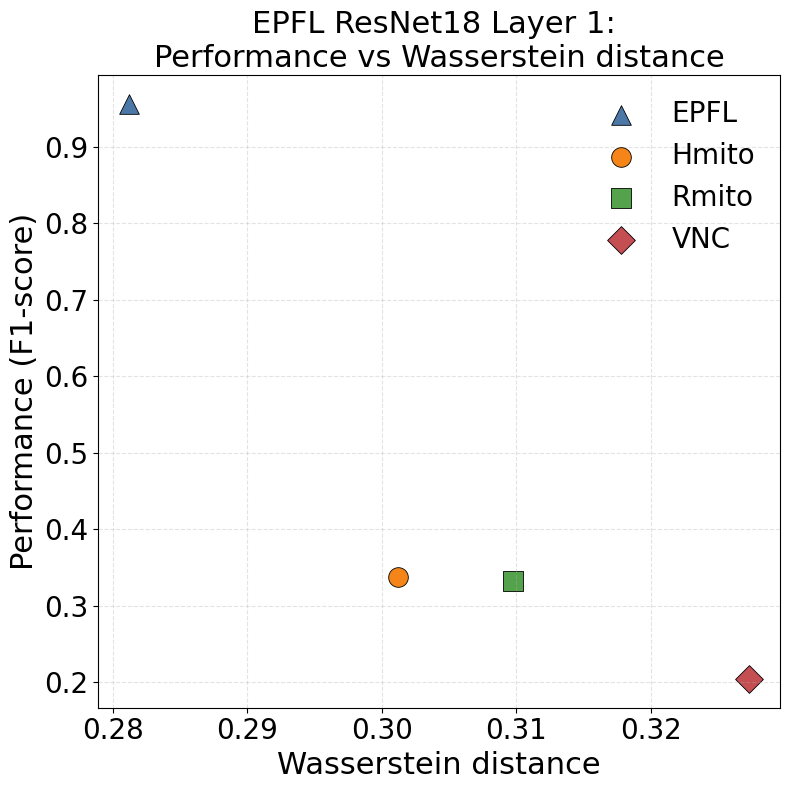

In [32]:
plot_performance_vs_dist(
    EPFL_f1s,
    EPFL_wass1,
    title="EPFL ResNet18 Layer 1: \nPerformance vs Wasserstein distance",
    save_name="EPFL_RN18_perf_vs_wass_layer1",
    fontsize=22,
    point_size=200,
    figsize=(8, 8),
    # x_ticks=[0.018, 0.019, 0.020, 0.021, 0.022]
)

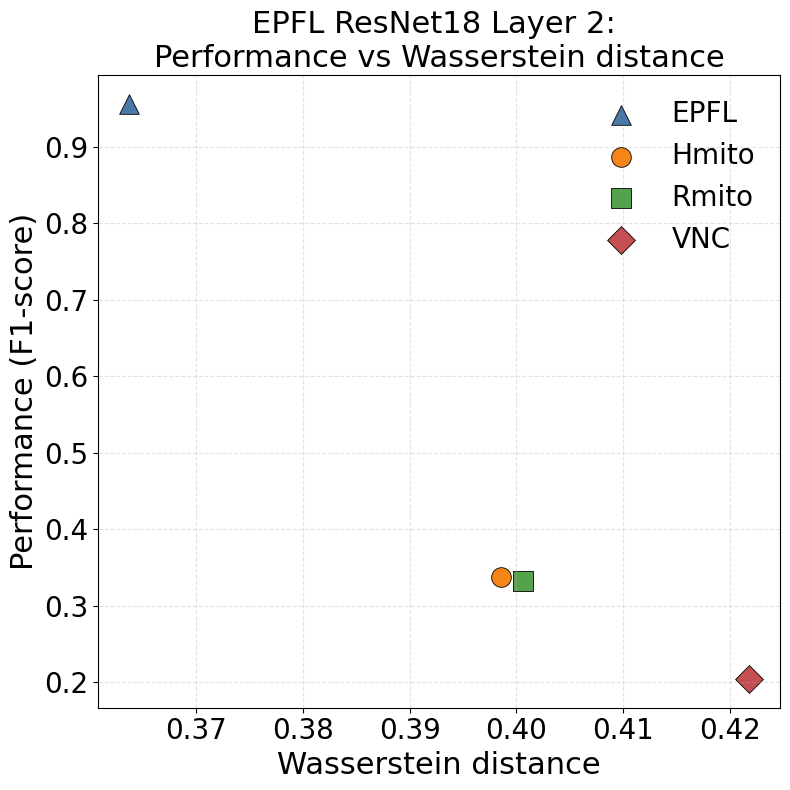

In [33]:
plot_performance_vs_dist(
    EPFL_f1s,
    EPFL_wass2,
    title="EPFL ResNet18 Layer 2: \nPerformance vs Wasserstein distance",
    save_name="EPFL_RN18_perf_vs_wass_layer2",
    fontsize=22,
    point_size=200,
    figsize=(8, 8),
    # x_ticks=[0.018, 0.019, 0.020, 0.021, 0.022]
)

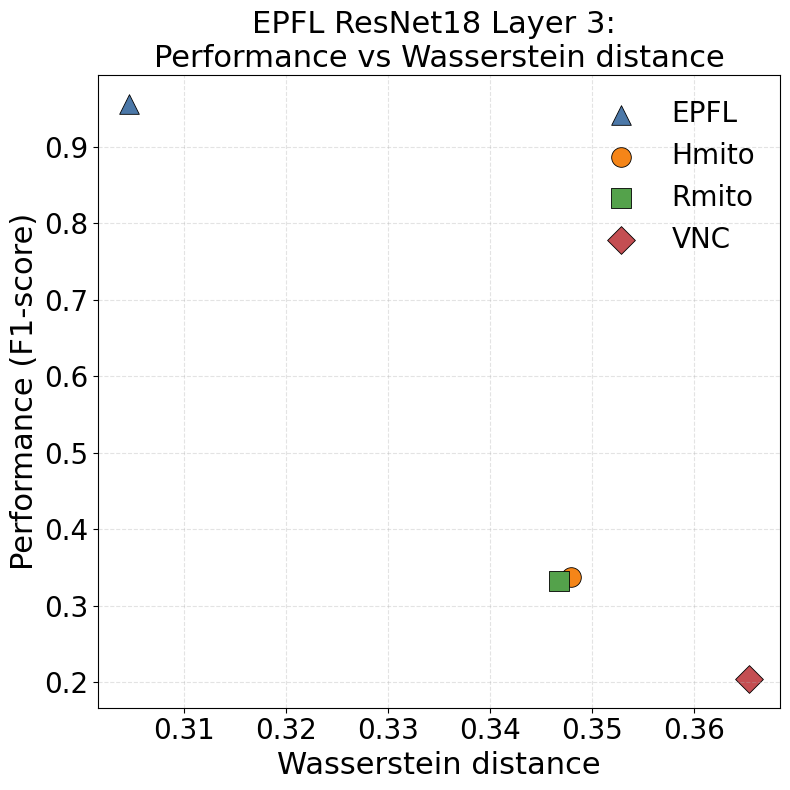

In [34]:
plot_performance_vs_dist(
    EPFL_f1s,
    EPFL_wass3,
    title="EPFL ResNet18 Layer 3: \nPerformance vs Wasserstein distance",
    save_name="EPFL_RN18_perf_vs_wass_layer3",
    fontsize=22,
    point_size=200,
    figsize=(8, 8),
    # x_ticks=[0.018, 0.019, 0.020, 0.021, 0.022]
)

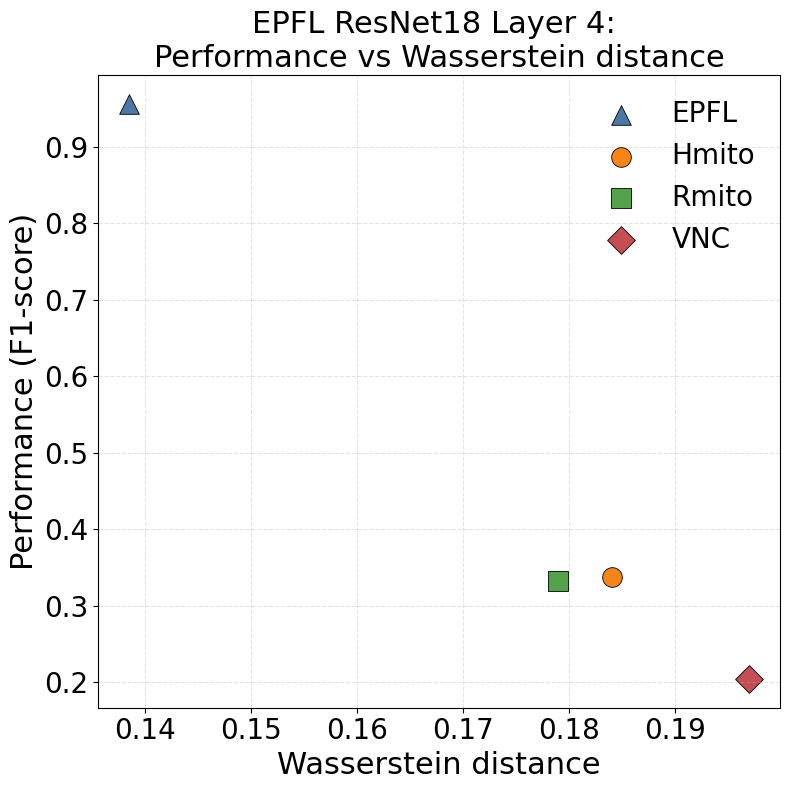

In [35]:
plot_performance_vs_dist(
    EPFL_f1s,
    EPFL_wass4,
    title="EPFL ResNet18 Layer 4: \nPerformance vs Wasserstein distance",
    save_name="EPFL_RN18_perf_vs_wass_layer4",
    fontsize=22,
    point_size=200,
    figsize=(8, 8),
    # x_ticks=[0.018, 0.019, 0.020, 0.021, 0.022]
)

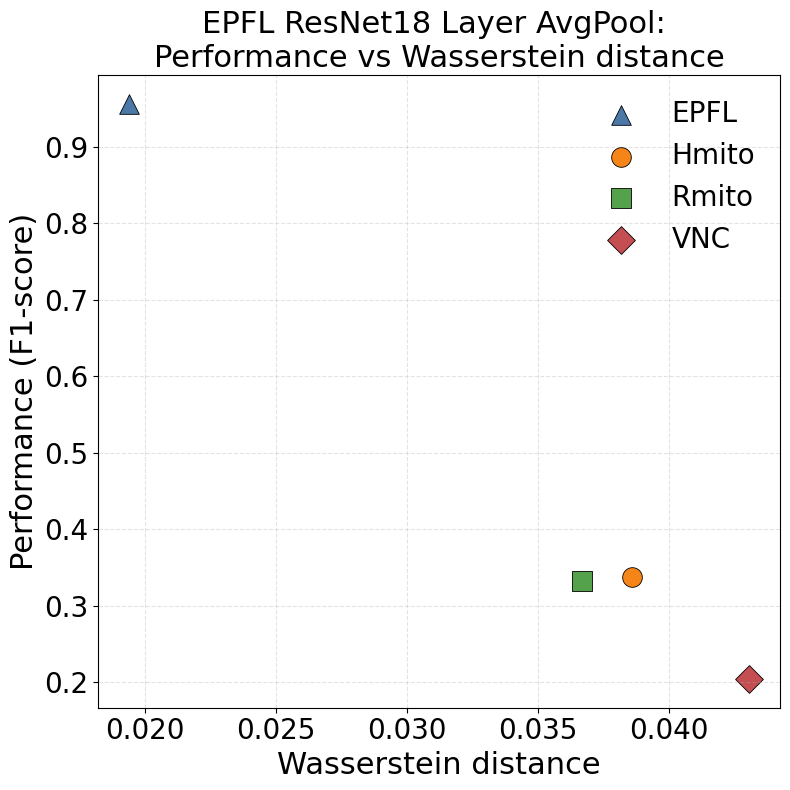

In [36]:
plot_performance_vs_dist(
    EPFL_f1s,
    EPFL_wass_avgpool,
    title="EPFL ResNet18 Layer AvgPool: \nPerformance vs Wasserstein distance",
    save_name="EPFL_RN18_perf_vs_wass_layer_avgpool",
    fontsize=22,
    point_size=200,
    figsize=(8, 8),
    # x_ticks=[0.018, 0.019, 0.020, 0.021, 0.022]
)

# Rmito

In [37]:
Rmito_f1s = {
    "EPFL": [RtoE_f1s[0]],
    "Hmito": [RtoH_f1s[0]],
    "Rmito": [RtoR_f1s[0]],
    "VNC": [RtoV_f1s[0]],
}
Rmito_wass1 = {
    "EPFL": [np.mean(RtoE_dists["layer1_1"], axis=0)],
    "Hmito": [np.mean(RtoH_dists["layer1_1"], axis=0)],
    "Rmito": [np.mean(RtoR_dists["layer1_1"], axis=0)],
    "VNC": [np.mean(RtoV_dists["layer1_1"], axis=0)],
}
Rmito_wass2 = {
    "EPFL": [np.mean(RtoE_dists["layer2_1"], axis=0)],
    "Hmito": [np.mean(RtoH_dists["layer2_1"], axis=0)],
    "Rmito": [np.mean(RtoR_dists["layer2_1"], axis=0)],
    "VNC": [np.mean(RtoV_dists["layer2_1"], axis=0)],
}
Rmito_wass3 = {
    "EPFL": [np.mean(RtoE_dists["layer3_1"], axis=0)],
    "Hmito": [np.mean(RtoH_dists["layer3_1"], axis=0)],
    "Rmito": [np.mean(RtoR_dists["layer3_1"], axis=0)],
    "VNC": [np.mean(RtoV_dists["layer3_1"], axis=0)],
}
Rmito_wass4 = {
    "EPFL": [np.mean(RtoE_dists["layer4_1"], axis=0)],
    "Hmito": [np.mean(RtoH_dists["layer4_1"], axis=0)],
    "Rmito": [np.mean(RtoR_dists["layer4_1"], axis=0)],
    "VNC": [np.mean(RtoV_dists["layer4_1"], axis=0)],
}
Rmito_wass_avgpool = {
    "EPFL": [np.mean(RtoE_dists["avgpool_1"], axis=0)],
    "Hmito": [np.mean(RtoH_dists["avgpool_1"], axis=0)],
    "Rmito": [np.mean(RtoR_dists["avgpool_1"], axis=0)],
    "VNC": [np.mean(RtoV_dists["avgpool_1"], axis=0)],
}

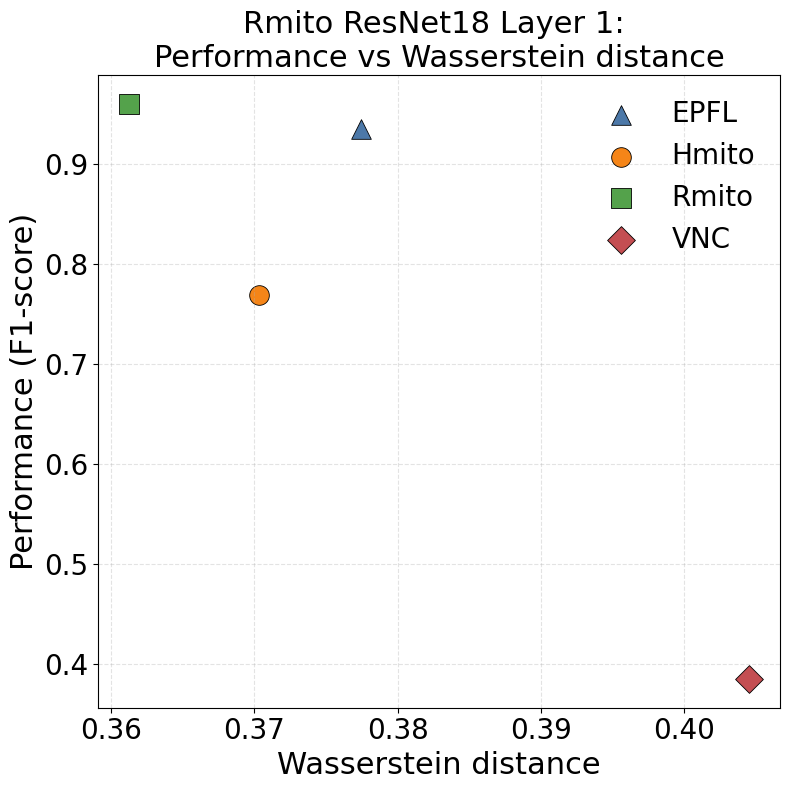

In [38]:
plot_performance_vs_dist(
    Rmito_f1s,
    Rmito_wass1,
    title="Rmito ResNet18 Layer 1: \nPerformance vs Wasserstein distance",
    save_name="Rmito_RN18_perf_vs_wass_layer1",
    fontsize=22,
    point_size=200,
    figsize=(8, 8),
    # x_ticks=[0.018, 0.019, 0.020, 0.021, 0.022]
)

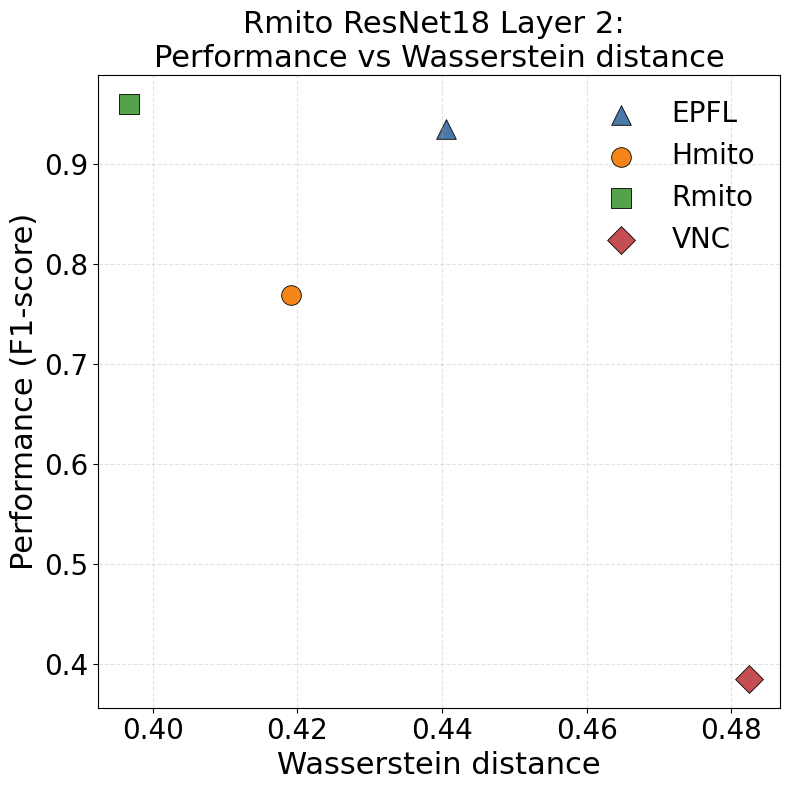

In [39]:
plot_performance_vs_dist(
    Rmito_f1s,
    Rmito_wass2,
    title="Rmito ResNet18 Layer 2: \nPerformance vs Wasserstein distance",
    save_name="Rmito_RN18_perf_vs_wass_layer2",
    fontsize=22,
    point_size=200,
    figsize=(8, 8),
    # x_ticks=[0.018, 0.019, 0.020, 0.021, 0.022]
)

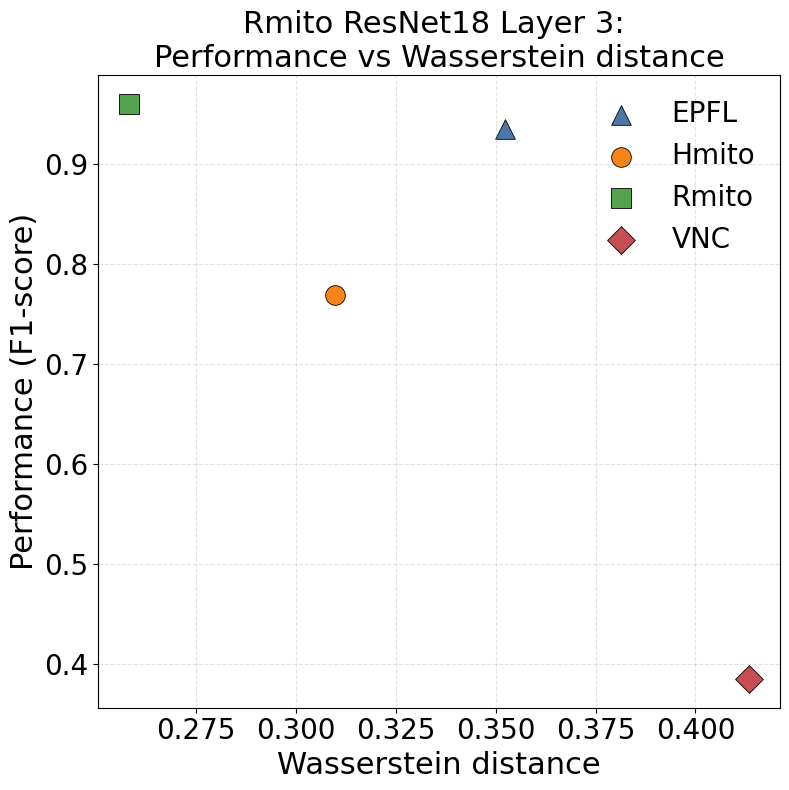

In [40]:
plot_performance_vs_dist(
    Rmito_f1s,
    Rmito_wass3,
    title="Rmito ResNet18 Layer 3: \nPerformance vs Wasserstein distance",
    save_name="Rmito_RN18_perf_vs_wass_layer3",
    fontsize=22,
    point_size=200,
    figsize=(8, 8),
    # x_ticks=[0.018, 0.019, 0.020, 0.021, 0.022]
)

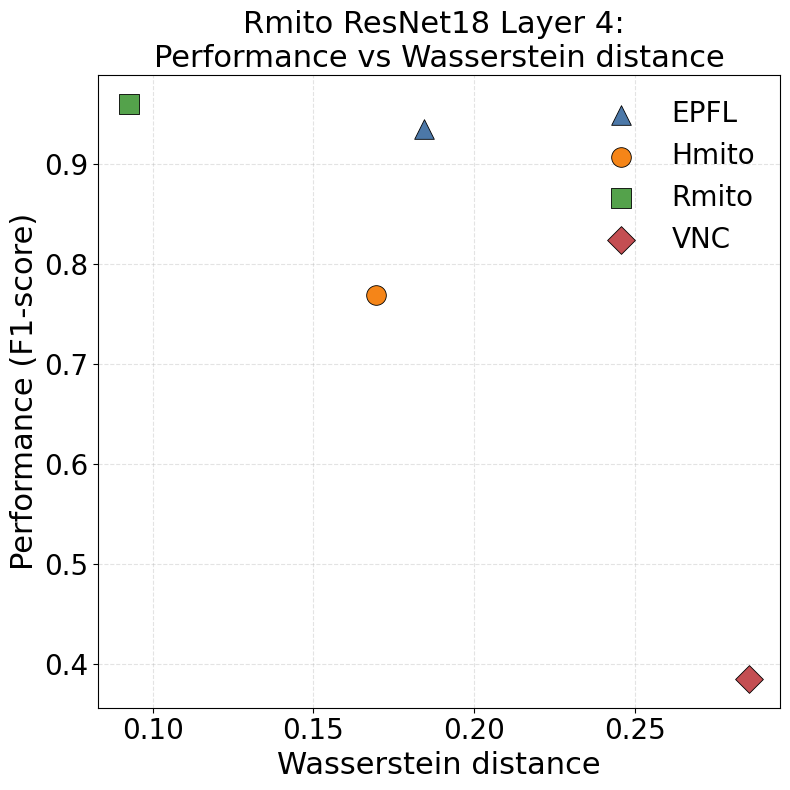

In [41]:
plot_performance_vs_dist(
    Rmito_f1s,
    Rmito_wass4,
    title="Rmito ResNet18 Layer 4: \nPerformance vs Wasserstein distance",
    save_name="Rmito_RN18_perf_vs_wass_layer4",
    fontsize=22,
    point_size=200,
    figsize=(8, 8),
    # x_ticks=[0.018, 0.019, 0.020, 0.021, 0.022]
)

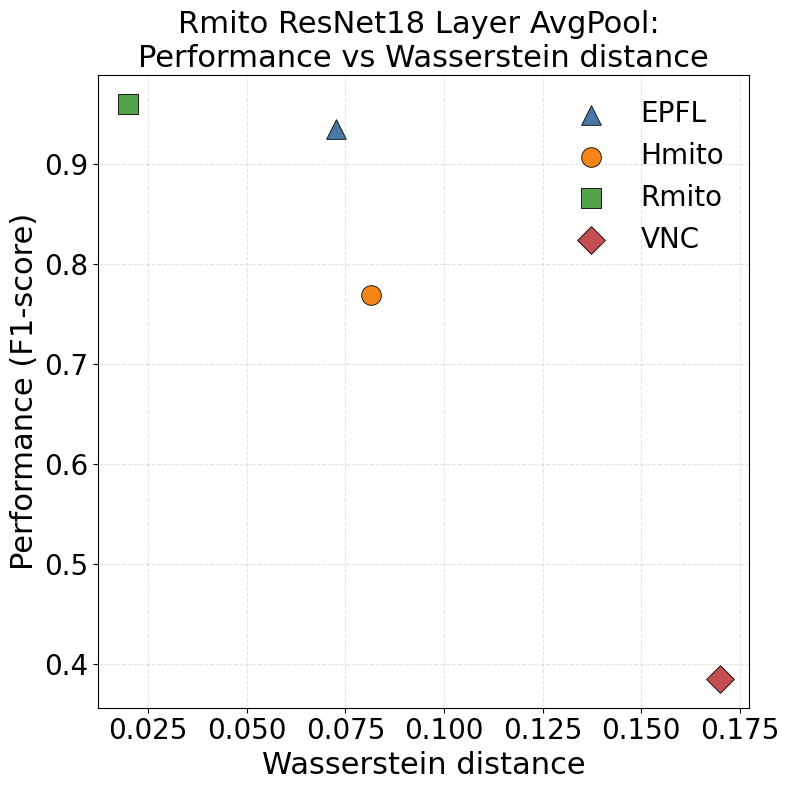

In [42]:
plot_performance_vs_dist(
    Rmito_f1s,
    Rmito_wass_avgpool,
    title="Rmito ResNet18 Layer AvgPool: \nPerformance vs Wasserstein distance",
    save_name="Rmito_RN18_perf_vs_wass_layer_avgpool",
    fontsize=22,
    point_size=200,
    figsize=(8, 8),
    # x_ticks=[0.018, 0.019, 0.020, 0.021, 0.022]
)

# Plot Wasserstein Distance vs F1 Score

In [6]:
target_datasets = ["epfl", "Hmito", "Rmito", "VNC"]

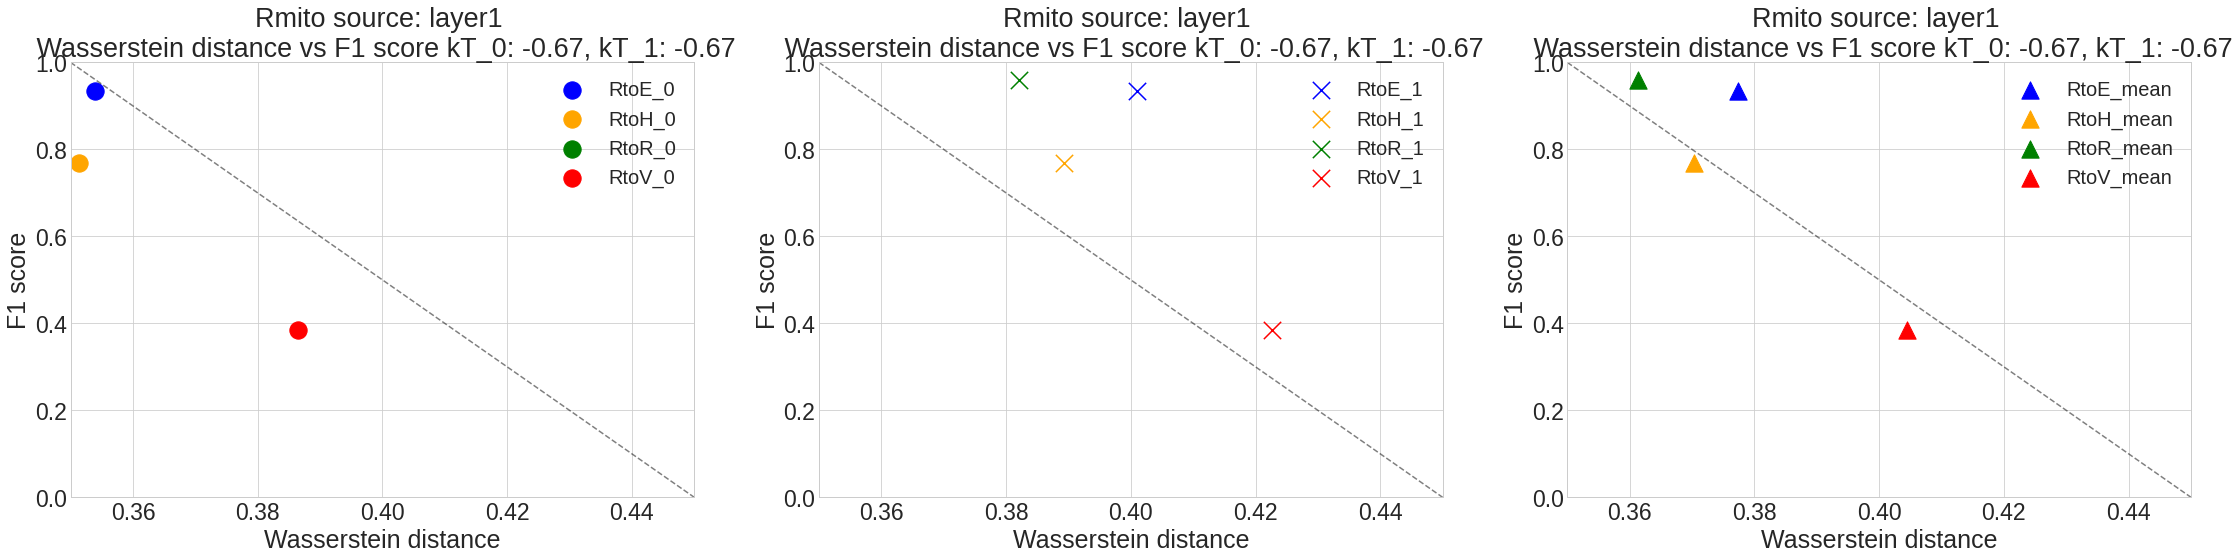

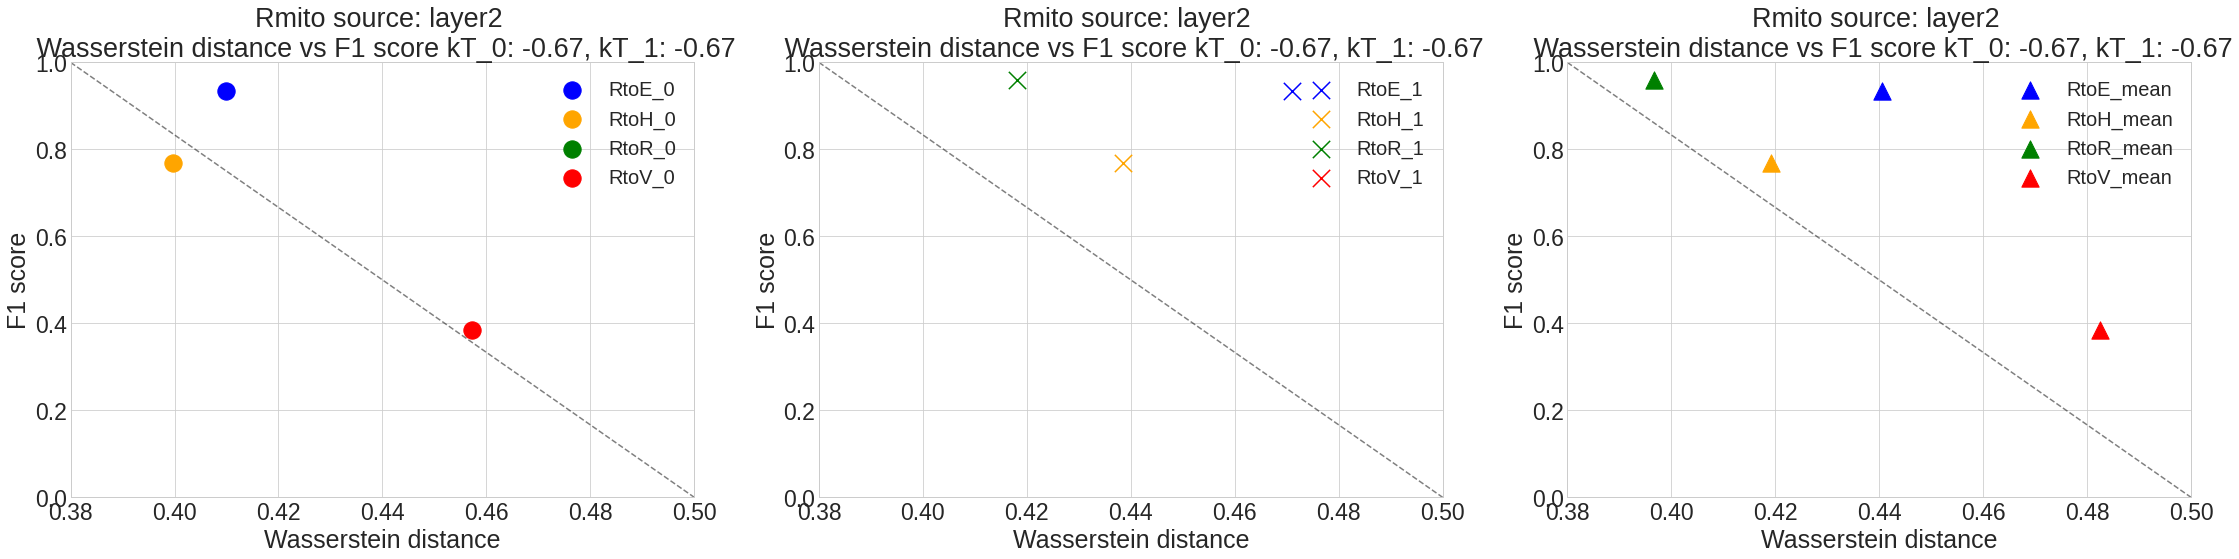

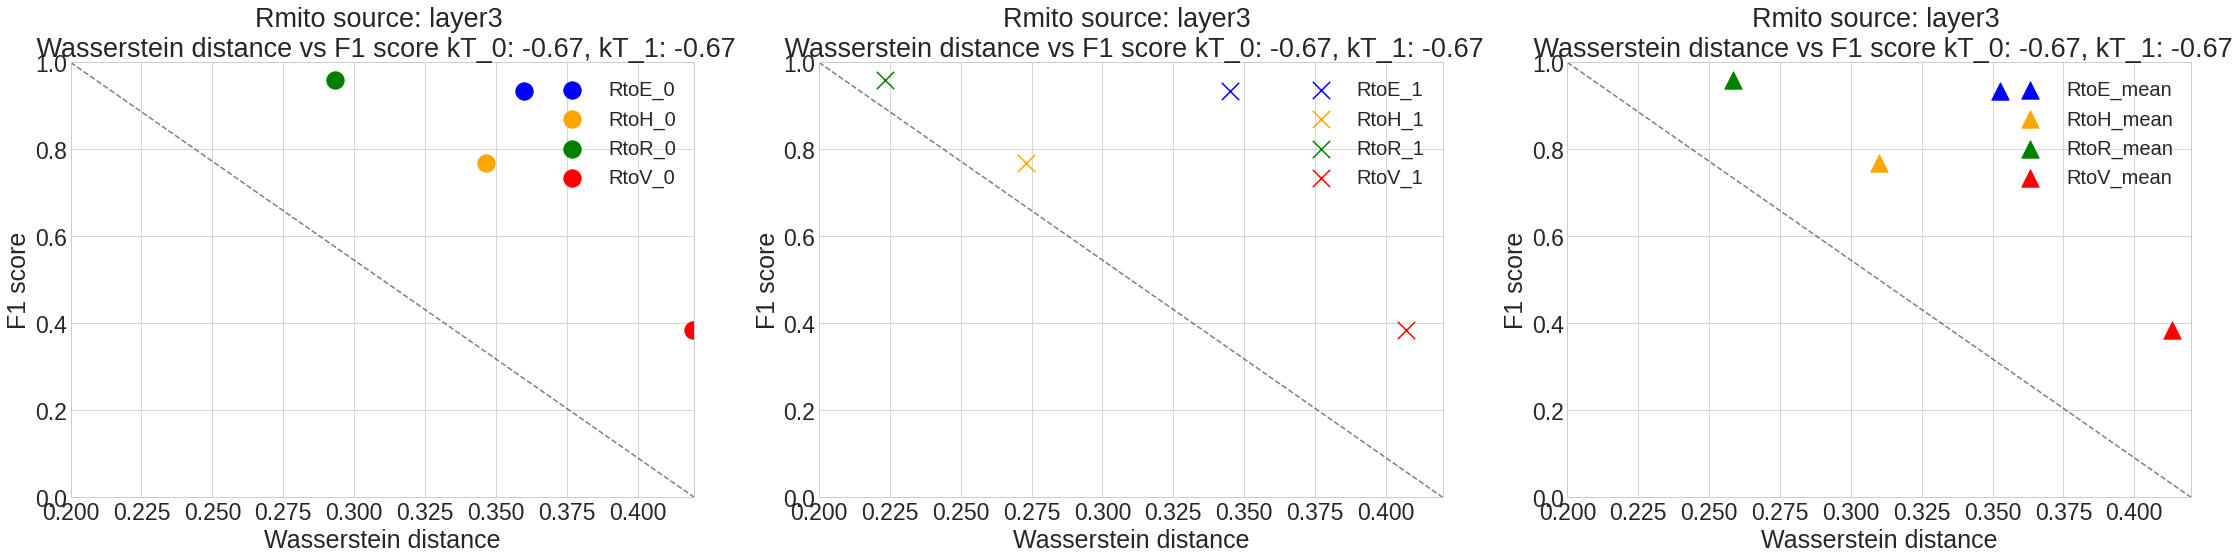

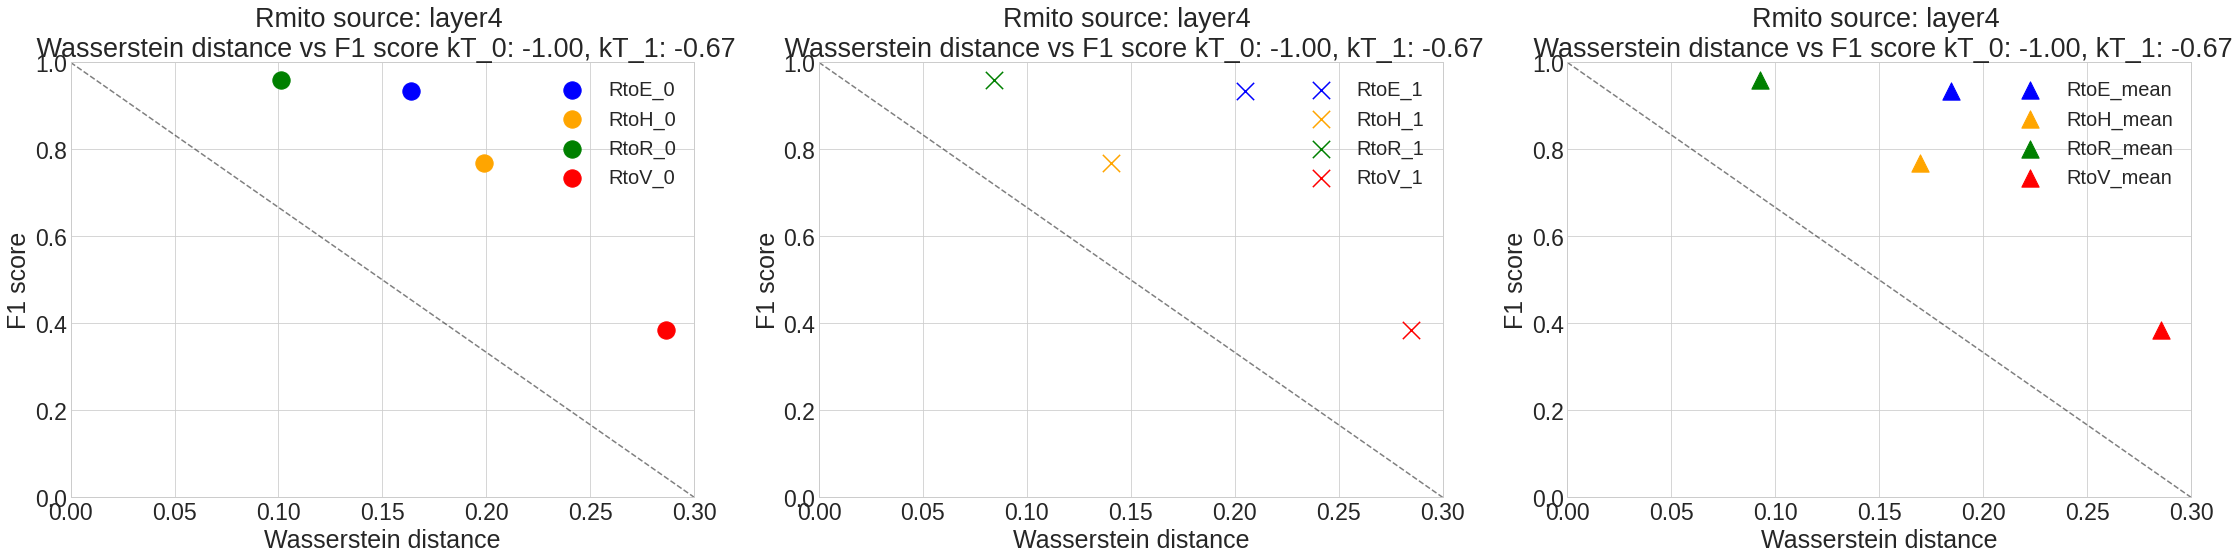

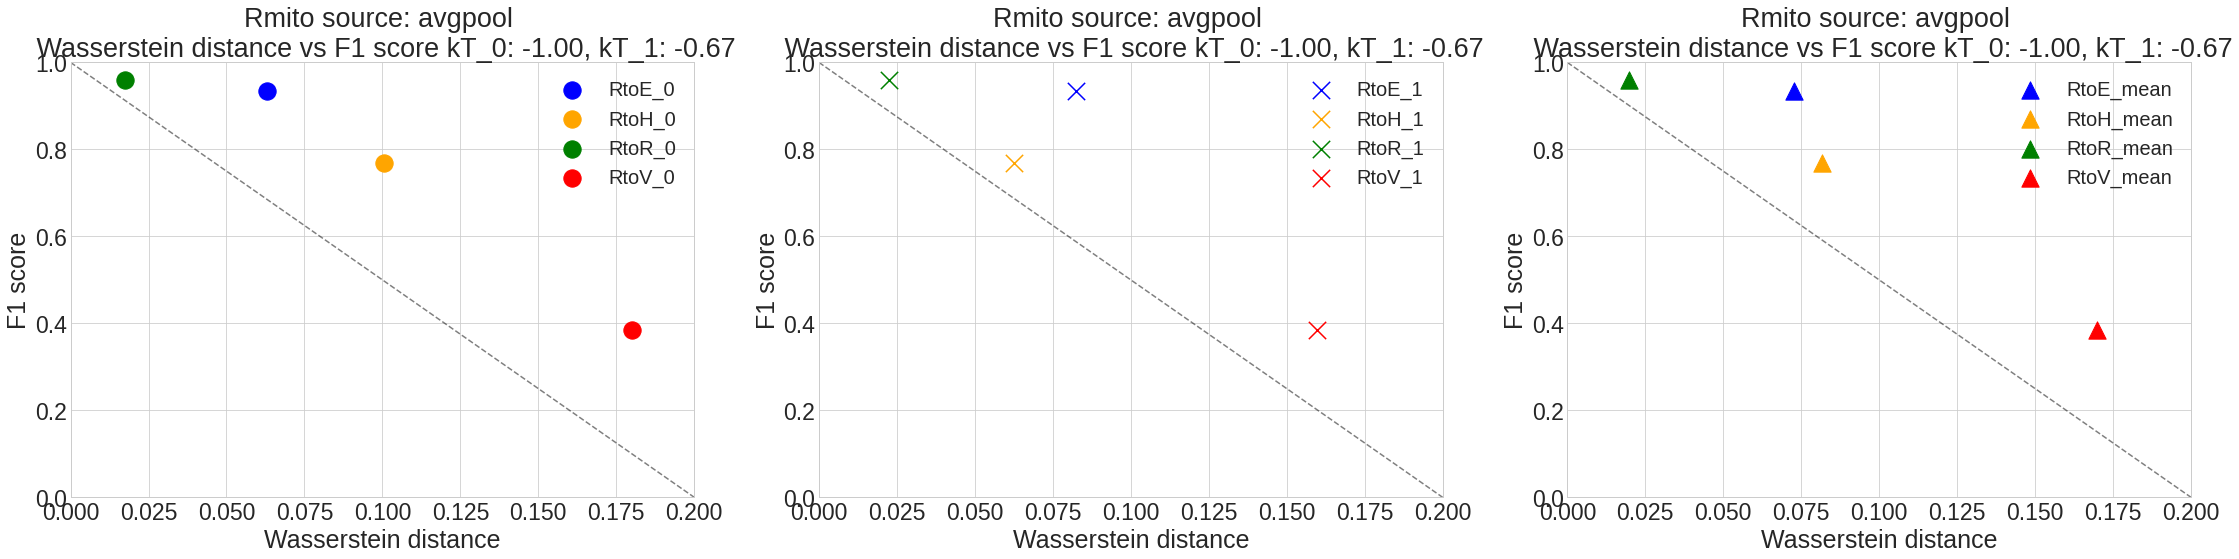

In [21]:
layers = ["layer1", "layer2", "layer3", "layer4", "avgpool"]
xlims = [(0.35,0.45), (0.38,0.5), (0.2,0.42), (0, 0.3), (0,0.2)]
sources = ['Rmito']
for source in sources:
    for i, layer in enumerate(layers):
        plot_Wassdist_layerwise(
            source,
            target_datasets,
            num_repeats=1,
            save_name_postfix='multi',
            plot_layer=layer,
            figsize=(38, 8),
            xlim=xlims[i],
            ylim=(0,1),
            fontsize=25,
            pointsize=300,
        )

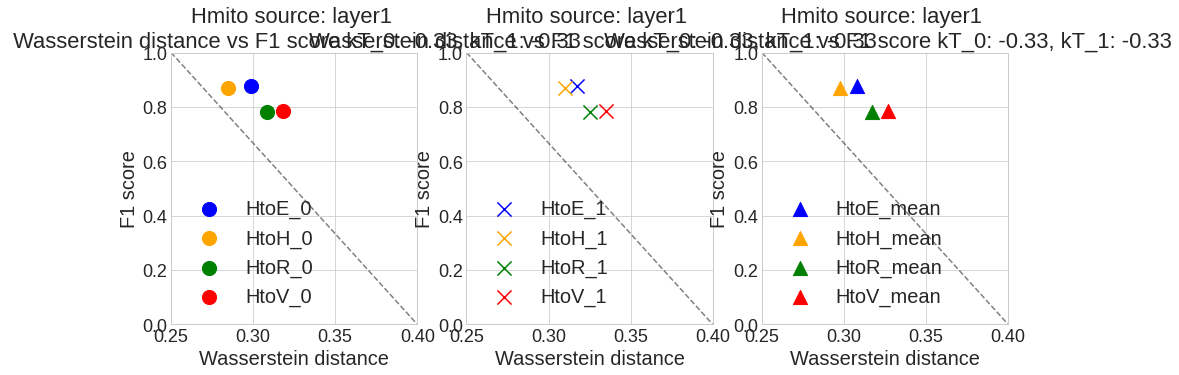

In [8]:
plot_Wassdist_layerwise(
    "Hmito", 
    target_datasets, 
    num_repeats=1, 
    save_name_postfix="multi", 
    plot_layer="layer1",
    xlim=(0.25, 0.4),
    ylim=(0, 1),
)

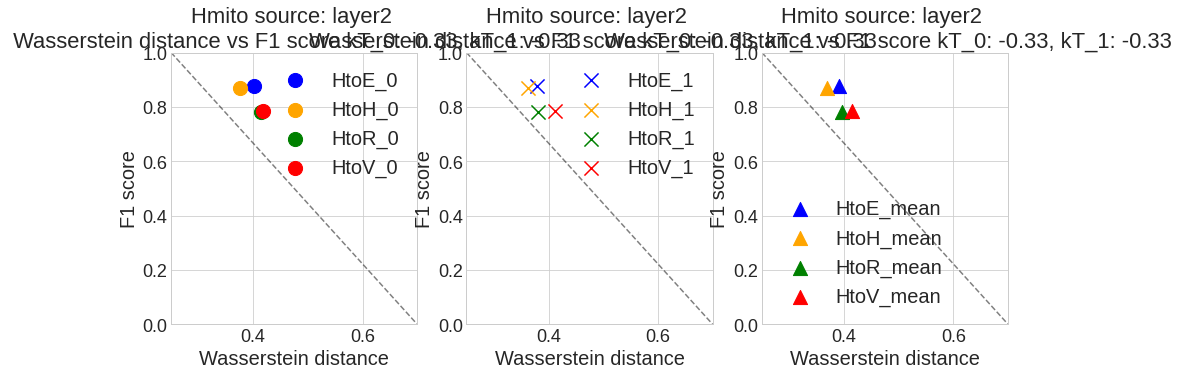

In [9]:
plot_Wassdist_layerwise(
    "Hmito", 
    target_datasets, 
    num_repeats=1, 
    save_name_postfix="multi", 
    plot_layer="layer2",
    xlim=(0.25, 0.7),
    ylim=(0, 1),
)

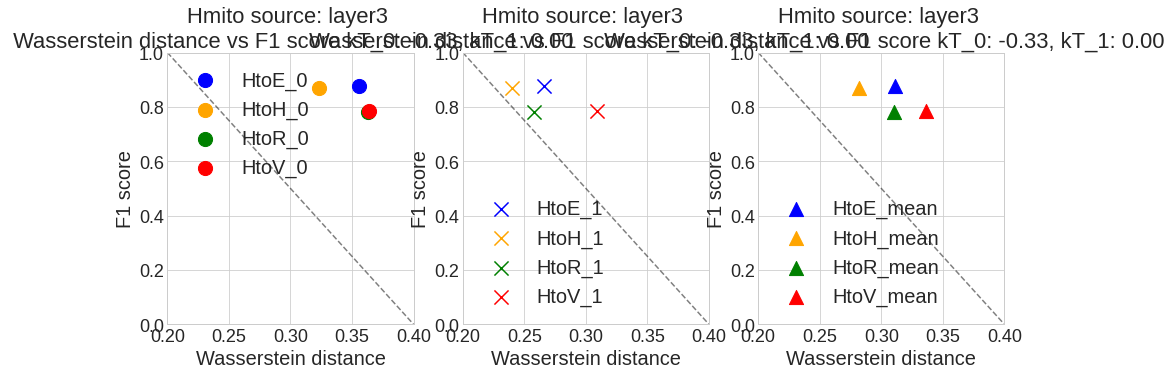

In [10]:
plot_Wassdist_layerwise(
    "Hmito", 
    target_datasets, 
    num_repeats=1, 
    save_name_postfix="multi", 
    plot_layer="layer3")

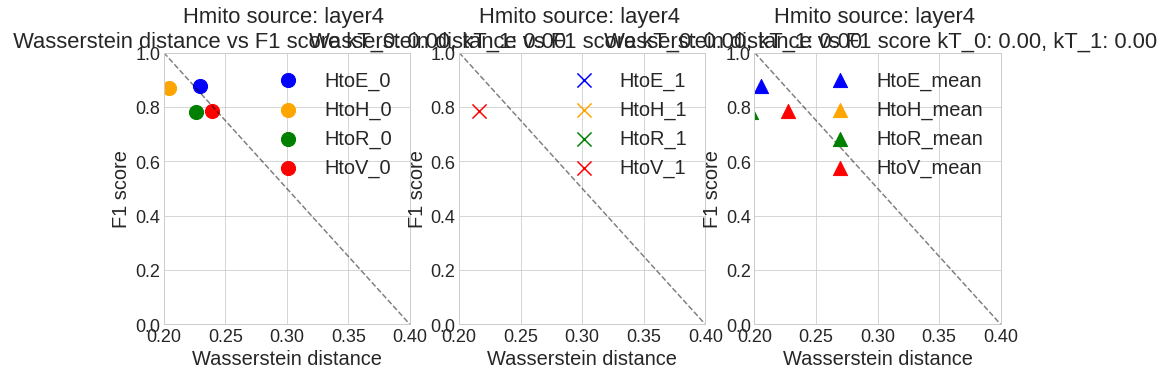

In [11]:
plot_Wassdist_layerwise(
    "Hmito", 
    target_datasets, 
    num_repeats=1, 
    save_name_postfix="multi", 
    plot_layer="layer4")

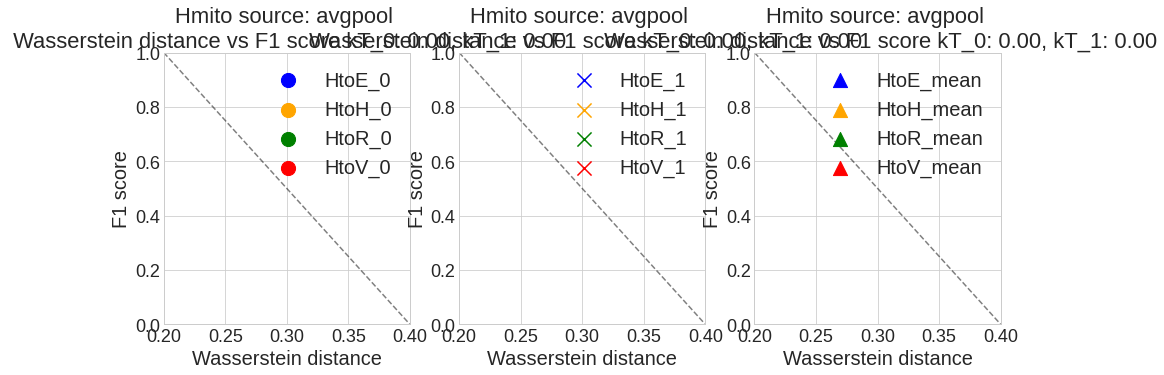

In [12]:
plot_Wassdist_layerwise(
    "Hmito", 
    target_datasets, 
    num_repeats=1, 
    save_name_postfix="multi", 
    plot_layer="avgpool")